# Projeto 2 – Classificação de uso de máscara com EfficientNetB0

Implementação deep learning no Projeto 1 de detecção de uso de máscara de Visão Computacional, utilizando o mesmo formato VOC e das mesmas imagens, o pipeline realiza o recorte das regiões de face, organiza os dados em conjuntos de treino, validação e teste, treina um modelo EfficientNetB0 com transfer learning e avalia o desempenho com métricas apropriadas como F1-macro, além de gerar exemplos anotados para comparação de resultados.

In [ ]:
from pathlib import Path
import xml.etree.ElementTree as ET

import pandas as pd
from sklearn.model_selection import train_test_split
from PIL import Image, ImageDraw, ImageFont

import numpy as np

import tensorflow as tf
from tensorflow.keras.preprocessing import image_dataset_from_directory
from tensorflow.keras import layers, models
from tensorflow.keras.applications.efficientnet import EfficientNetB0, preprocess_input

from sklearn.metrics import classification_report, f1_score, confusion_matrix

ROOT = Path("..").resolve()

ANNOT_DIR = ROOT / "data" / "raw" / "annotations"
IMAGES_DIR = ROOT / "data" / "raw" / "images"
ROI_DIR = ROOT / "data" / "interim" / "roi_face_project2"

MODELS_DIR = ROOT / "models" / "project2"
MODELS_DIR.mkdir(parents=True, exist_ok=True)

REPORTS_FIG_DIR = ROOT / "reports" / "figures" / "project2"
REPORTS_FIG_DIR.mkdir(parents=True, exist_ok=True)

print("ROOT:", ROOT)
print("Annotations:", ANNOT_DIR)
print("Images:", IMAGES_DIR)
print("ROI Project2:", ROI_DIR)
print("Models Project2:", MODELS_DIR)
print("Figures Project2:", REPORTS_FIG_DIR)

print("\nVersão do TensorFlow:", tf.__version__)

ROOT: C:\Users\Fernanda\Desktop\projeto_mascara
Annotations: C:\Users\Fernanda\Desktop\projeto_mascara\data\raw\annotations
Images: C:\Users\Fernanda\Desktop\projeto_mascara\data\raw\images
ROI Project2: C:\Users\Fernanda\Desktop\projeto_mascara\data\interim\roi_face_project2
Models Project2: C:\Users\Fernanda\Desktop\projeto_mascara\models\project2
Figures Project2: C:\Users\Fernanda\Desktop\projeto_mascara\reports\figures\project2

Versão do TensorFlow: 2.20.0


## 1. Preparação dos dados (anotações VOC → recortes de face)

As anotações estão no data/raw/annotations e as imagens em data/raw/images, com bounding boxes para faces com labels como with_mask, without_mask e mask_weared_incorrect.  

In [ ]:
def parse_annotation(xml_path: Path):
    """
    Lê um arquivo XML no formato VOC e retorna uma lista de objetos com:
    filename, label, xmin, ymin, xmax, ymax.
    """
    tree = ET.parse(xml_path)
    root = tree.getroot()

    filename = root.find("filename").text
    objects = []

    for obj in root.findall("object"):
        label = obj.find("name").text 
        bndbox = obj.find("bndbox")
        xmin = int(float(bndbox.find("xmin").text))
        ymin = int(float(bndbox.find("ymin").text))
        xmax = int(float(bndbox.find("xmax").text))
        ymax = int(float(bndbox.find("ymax").text))

        objects.append(
            {
                "filename": filename,
                "label": label,
                "xmin": xmin,
                "ymin": ymin,
                "xmax": xmax,
                "ymax": ymax,
            }
        )

    return objects


In [ ]:

# Célula 5 – Código: ler todas as anotações e montar o DataFrame
xml_files = sorted(ANNOT_DIR.glob("*.xml"))
print("Quantidade de arquivos de anotação (XML):", len(xml_files))

all_records = []

for xml_path in xml_files:
    objs = parse_annotation(xml_path)
    all_records.extend(objs)

df_faces = pd.DataFrame(all_records)
print("Amostras totais (faces):", len(df_faces))
df_faces.head()

Quantidade de arquivos de anotação (XML): 853
Amostras totais (faces): 4072


,filename,label,xmin,ymin,xmax,ymax
0,maksssksksss0.png,without_mask,79,105,109,142
1,maksssksksss0.png,with_mask,185,100,226,144
2,maksssksksss0.png,without_mask,325,90,360,141
3,maksssksksss1.png,with_mask,321,34,354,69
4,maksssksksss1.png,with_mask,224,38,261,73


In [12]:
#Célula 6 – Código: distribuição de classes
df_faces["label"].value_counts()

label
with_mask                3232
without_mask              717
mask_weared_incorrect     123
Name: count, dtype: int64

In [ ]:

# Célula 7 – Código: split estratificado em train / val / test

train_val_df, test_df = train_test_split(
    df_faces,
    test_size=0.15,
    stratify=df_faces["label"],
    random_state=42,
)

train_df, val_df = train_test_split(
    train_val_df,
    test_size=0.1765, 
    stratify=train_val_df["label"],
    random_state=42,
)

for name, part in [("train", train_df), ("val", val_df), ("test", test_df)]:
    print("=== Split:", name, "===")
    print("Total de amostras:", len(part))
    print(part["label"].value_counts(), "\n")


=== Split: train ===
Total de amostras: 2850
label
with_mask                2262
without_mask              502
mask_weared_incorrect      86
Name: count, dtype: int64 

=== Split: val ===
Total de amostras: 611
label
with_mask                485
without_mask             107
mask_weared_incorrect     19
Name: count, dtype: int64 

=== Split: test ===
Total de amostras: 611
label
with_mask                485
without_mask             108
mask_weared_incorrect     18
Name: count, dtype: int64 



In [ ]:
# 8 – Código: função para recortar e salvar faces
def save_crops(split_name: str, split_df: pd.DataFrame, base_roi_dir: Path, images_dir: Path):
    """
    Para cada amostra em split_df, recorta a região da face na imagem original
    e salva em base_roi_dir/split_name/label/.
    """
    split_dir = base_roi_dir / split_name

    for label in split_df["label"].unique():
        (split_dir / label).mkdir(parents=True, exist_ok=True)

    for idx, row in split_df.iterrows():
        img_path = images_dir / row["filename"]

        if not img_path.exists():
            print("Imagem não encontrada:", img_path)
            continue

        try:
            img = Image.open(img_path).convert("RGB")
        except Exception as e:
            print("Erro ao abrir imagem:", img_path, e)
            continue

        width, height = img.size
        xmin = max(0, row["xmin"])
        ymin = max(0, row["ymin"])
        xmax = min(width, row["xmax"])
        ymax = min(height, row["ymax"])

        if xmax <= xmin or ymax <= ymin:
            print("Bounding box inválido em", img_path, row.to_dict())
            continue

        crop = img.crop((xmin, ymin, xmax, ymax))

        stem = Path(row["filename"]).stem
        label = row["label"]

        out_name = f"{stem}_{idx}.jpg"
        out_path = split_dir / label / out_name

        try:
            crop.save(out_path)
        except Exception as e:
            print("Erro ao salvar recorte em", out_path, e)

In [ ]:

# 9 – Código: gerar os recortes para train / val / test
save_crops("train", train_df, ROI_DIR, IMAGES_DIR)
save_crops("val", val_df, ROI_DIR, IMAGES_DIR)
save_crops("test", test_df, ROI_DIR, IMAGES_DIR)

for split in ["train", "val", "test"]:
    print("=== Split:", split, "===")
    for label in sorted(df_faces["label"].unique()):
        count = len(list((ROI_DIR / split / label).glob("*.jpg")))
        print(f"{label}: {count}")
    print()


=== Split: train ===
mask_weared_incorrect: 86
with_mask: 2262
without_mask: 502

=== Split: val ===
mask_weared_incorrect: 19
with_mask: 485
without_mask: 107

=== Split: test ===
mask_weared_incorrect: 18
with_mask: 485
without_mask: 108



## 2. Montagem do dataset para aprendizado profundo

Os recortes de rosto foram gerados e estão no data/interim/roi_face_project2, agora é feita a construção dos conjuntos de treino, validação e teste no formato esperado pelo TensorFlow, açlém de que é usado o image_dataset_from_directory para ler automaticamente as subpastas como classes.

In [16]:
#11 – Código: carregar os datasets

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

train_dir = ROI_DIR / "train"
val_dir = ROI_DIR / "val"
test_dir = ROI_DIR / "test"

train_ds = image_dataset_from_directory(
    train_dir,
    label_mode="int",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True,
)

val_ds = image_dataset_from_directory(
    val_dir,
    label_mode="int",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False,
)

test_ds = image_dataset_from_directory(
    test_dir,
    label_mode="int",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False,
)

class_names = train_ds.class_names
class_names


Found 2850 files belonging to 3 classes.
Found 611 files belonging to 3 classes.
Found 611 files belonging to 3 classes.


['mask_weared_incorrect', 'with_mask', 'without_mask']

In [17]:
# 12 – Código: cache, prefetch e data augmentation
AUTOTUNE = tf.data.AUTOTUNE

def prepare_for_training(ds, shuffle=False):
    if shuffle:
        ds = ds.shuffle(1000)
    ds = ds.cache().prefetch(buffer_size=AUTOTUNE)
    return ds

train_ds_base = prepare_for_training(train_ds, shuffle=True)
val_ds_base = prepare_for_training(val_ds)
test_ds_base = prepare_for_training(test_ds)

data_augmentation = tf.keras.Sequential(
    [
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(0.05),
        layers.RandomZoom(0.1),
        layers.RandomContrast(0.1),
    ],
    name="data_augmentation",
)

def preprocess_batch(images, labels):
    images = preprocess_input(images)
    return images, labels

train_ds_final = train_ds_base.map(
    lambda x, y: (data_augmentation(x, training=True), y)
).map(preprocess_batch)

val_ds_final = val_ds_base.map(preprocess_batch)
test_ds_final = test_ds_base.map(preprocess_batch)

## 3. Modelo EfficientNetB0 com *transfer learning*

Foi montado um modelo com EfficientNetB0 pré-treinado no ImageNet, foi feita a remoção da cabeça original de classificação e adicionado uma nova cabeça com saída para as três classes.
O treinamento é feito em duas fases:  

1. Fase 1: Nova cabeça é treinada com a base convolucional congelada;  
2. Fase 2: Parte das camadas finais da EfficientNetB0 é descongelada e arrumada com uma taxa de aprendizado menor para melhorar a performance final e equilibrar melhor o desempenho entre as classes.

In [ ]:
#14 – Código: definir o modelo
num_classes = len(class_names)

base_model = EfficientNetB0(
    include_top=False,
    weights="imagenet",
    input_shape=IMG_SIZE + (3,),
)

base_model.trainable = False 

inputs = layers.Input(shape=IMG_SIZE + (3,), name="input_image")
x = base_model(inputs, training=False)
x = layers.GlobalAveragePooling2D(name="global_avg_pool")(x)
x = layers.Dropout(0.3, name="dropout")(x)
x = layers.Dense(128, activation="relu", name="dense_128")(x)
outputs = layers.Dense(num_classes, activation="softmax", name="predictions")(x)

model = models.Model(inputs, outputs, name="efficientnetb0_mask_classifier")

model.summary()

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "efficientnetb0_mask_classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_image (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_avg_pool                 │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_128 (Dense)               │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ predictions (Dense)             │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,213,926 (16.07 MB)

 Trainable params: 164,355 (642.01 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [19]:
#15 – Código: compilar e treinar (fase 1)
checkpoint_path = MODELS_DIR / "efficientnet_b0.h5"

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        filepath=str(checkpoint_path),
        monitor="val_accuracy",
        save_best_only=True,
        save_weights_only=False,
        verbose=1,
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=3,
        restore_best_weights=True,
        verbose=1,
    ),
]

initial_epochs = 10

history_1 = model.fit(
    train_ds_final,
    validation_data=val_ds_final,
    epochs=initial_epochs,
    callbacks=callbacks,
)

Epoch 1/10
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 693ms/step - accuracy: 0.8091 - loss: 0.4726
Epoch 1: val_accuracy improved from None to 0.91489, saving model to C:\Users\Fernanda\Desktop\projeto_mascara\models\project2\efficientnet_b0.h5


90/90 ━━━━━━━━━━━━━━━━━━━━ 90s 870ms/step - accuracy: 0.8684 - loss: 0.3623 - val_accuracy: 0.9149 - val_loss: 0.2877
Epoch 2/10
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 667ms/step - accuracy: 0.9065 - loss: 0.2632
Epoch 2: val_accuracy did not improve from 0.91489
90/90 ━━━━━━━━━━━━━━━━━━━━ 73s 814ms/step - accuracy: 0.9028 - loss: 0.2687 - val_accuracy: 0.9133 - val_loss: 0.2578
Epoch 3/10
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 738ms/step - accuracy: 0.9164 - loss: 0.2254
Epoch 3: val_accuracy did not improve from 0.91489
90/90 ━━━━━━━━━━━━━━━━━━━━ 79s 879ms/step - accuracy: 0.9168 - loss: 0.2237 - val_accuracy: 0.9149 - val_loss: 0.2183
Epoch 4/10
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 727ms/step - accuracy: 0.9229 - loss: 0.1991
Epoch 4: val_accuracy improved from 0.91489 to 0.92471, saving model to C:\Users\Fernanda\Desktop\projeto_mascara\models\project2\efficientnet_b0.h5


90/90 ━━━━━━━━━━━━━━━━━━━━ 81s 894ms/step - accuracy: 0.9200 - loss: 0.2135 - val_accuracy: 0.9247 - val_loss: 0.2214
Epoch 5/10
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9207 - loss: 0.1988
Epoch 5: val_accuracy did not improve from 0.92471
90/90 ━━━━━━━━━━━━━━━━━━━━ 113s 1s/step - accuracy: 0.9232 - loss: 0.2017 - val_accuracy: 0.9149 - val_loss: 0.2372
Epoch 6/10
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 994ms/step - accuracy: 0.9293 - loss: 0.1814
Epoch 6: val_accuracy did not improve from 0.92471
90/90 ━━━━━━━━━━━━━━━━━━━━ 107s 1s/step - accuracy: 0.9274 - loss: 0.1918 - val_accuracy: 0.9165 - val_loss: 0.2286
Epoch 7/10
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 986ms/step - accuracy: 0.9291 - loss: 0.1842
Epoch 7: val_accuracy improved from 0.92471 to 0.94108, saving model to C:\Users\Fernanda\Desktop\projeto_mascara\models\project2\efficientnet_b0.h5


90/90 ━━━━━━━━━━━━━━━━━━━━ 107s 1s/step - accuracy: 0.9211 - loss: 0.1953 - val_accuracy: 0.9411 - val_loss: 0.1891
Epoch 8/10
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9312 - loss: 0.1831
Epoch 8: val_accuracy did not improve from 0.94108
90/90 ━━━━━━━━━━━━━━━━━━━━ 111s 1s/step - accuracy: 0.9270 - loss: 0.1912 - val_accuracy: 0.9100 - val_loss: 0.2317
Epoch 9/10
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9289 - loss: 0.1854
Epoch 9: val_accuracy did not improve from 0.94108
90/90 ━━━━━━━━━━━━━━━━━━━━ 109s 1s/step - accuracy: 0.9302 - loss: 0.1885 - val_accuracy: 0.9182 - val_loss: 0.2135
Epoch 10/10
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9367 - loss: 0.1741
Epoch 10: val_accuracy did not improve from 0.94108
90/90 ━━━━━━━━━━━━━━━━━━━━ 108s 1s/step - accuracy: 0.9277 - loss: 0.1840 - val_accuracy: 0.9231 - val_loss: 0.2457
Epoch 10: early stopping
Restoring model weights from the end of the best epoch: 7.


In [ ]:
#16 – Código: fine tuning (fase 2)
model = tf.keras.models.load_model(checkpoint_path)

base_model = model.layers[1]

base_model.trainable = True

fine_tune_at = 200 
for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

fine_tune_epochs = 5

history_2 = model.fit(
    train_ds_final,
    validation_data=val_ds_final,
    epochs=fine_tune_epochs,
    callbacks=callbacks,
)

Epoch 1/5
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 914ms/step - accuracy: 0.5834 - loss: 1.0693
Epoch 1: val_accuracy did not improve from 0.94108
90/90 ━━━━━━━━━━━━━━━━━━━━ 108s 1s/step - accuracy: 0.6270 - loss: 0.9273 - val_accuracy: 0.8838 - val_loss: 0.4010
Epoch 2/5
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 846ms/step - accuracy: 0.7429 - loss: 0.5999
Epoch 2: val_accuracy did not improve from 0.94108
90/90 ━━━━━━━━━━━━━━━━━━━━ 89s 985ms/step - accuracy: 0.7667 - loss: 0.5725 - val_accuracy: 0.8838 - val_loss: 0.3654
Epoch 3/5
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 958ms/step - accuracy: 0.8225 - loss: 0.4409
Epoch 3: val_accuracy did not improve from 0.94108
90/90 ━━━━━━━━━━━━━━━━━━━━ 99s 1s/step - accuracy: 0.8305 - loss: 0.4499 - val_accuracy: 0.8871 - val_loss: 0.3337
Epoch 3: early stopping
Restoring model weights from the end of the best epoch: 1.


## 4. Avaliação no conjunto de teste

In [22]:
#18 – Código: métricas no conjunto de teste
best_model = tf.keras.models.load_model(checkpoint_path)

test_loss, test_acc = best_model.evaluate(test_ds_final)
print("Loss de teste:", test_loss)
print("Acurácia de teste:", test_acc)

20/20 ━━━━━━━━━━━━━━━━━━━━ 17s 674ms/step - accuracy: 0.7954 - loss: 0.4751
Loss de teste: 0.4751174747943878
Acurácia de teste: 0.7954173684120178


In [23]:
#19 – Código: F1, relatório de classificação e matriz de confusão
y_true = []
y_pred = []

for batch_images, batch_labels in test_ds_final:
    preds = best_model.predict(batch_images, verbose=0)
    preds_labels = np.argmax(preds, axis=1)
    y_true.extend(batch_labels.numpy())
    y_pred.extend(preds_labels)

y_true = np.array(y_true)
y_pred = np.array(y_pred)

print("F1-macro:", f1_score(y_true, y_pred, average="macro"))
print("\nRelatório de classificação:\n")
print(classification_report(y_true, y_pred, target_names=class_names))

cm = confusion_matrix(y_true, y_pred)
cm

F1-macro: 0.5380817736583815

Relatório de classificação:

                       precision    recall  f1-score   support

mask_weared_incorrect       1.00      0.06      0.11        18
            with_mask       0.96      0.79      0.87       485
         without_mask       0.49      0.95      0.64       108

             accuracy                           0.80       611
            macro avg       0.82      0.60      0.54       611
         weighted avg       0.88      0.80      0.80       611



array([[  1,  11,   6],
       [  0, 382, 103],
       [  0,   5, 103]])

Figura salva em: C:\Users\Fernanda\Desktop\projeto_mascara\reports\figures\project2\confusion_matrix_proj2.png


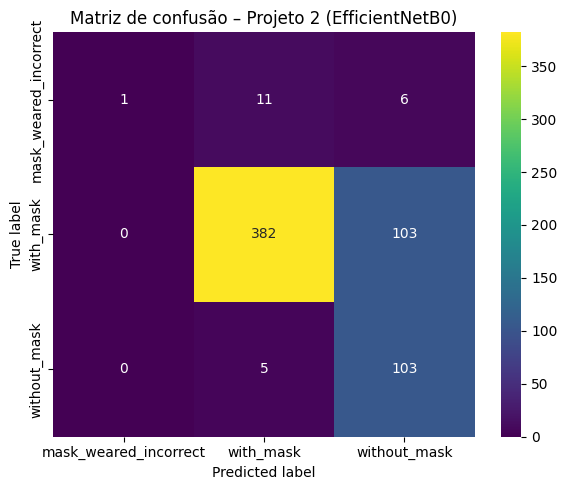

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="viridis",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.title("Matriz de confusão – Projeto 2 (EfficientNetB0)")
plt.tight_layout()

save_path = REPORTS_FIG_DIR / "confusion_matrix_proj2.png"
plt.savefig(save_path, dpi=300, bbox_inches="tight")
print("Figura salva em:", save_path)

plt.show()

## 5. Geração de exemplos anotados em imagens completas

In [ ]:
#21 – Código: função para anotar imagens
def annotate_image(image_path: Path, xml_path: Path, model, class_names, out_dir: Path, max_faces: int = None):
    """
    Lê uma imagem e seu XML correspondente, classifica cada face anotada e
    desenha bounding boxes com os rótulos previstos.
    """
    img = Image.open(image_path).convert("RGB")
    draw = ImageDraw.Draw(img)

    tree = ET.parse(xml_path)
    root = tree.getroot()

    faces = []
    for obj in root.findall("object"):
        label_true = obj.find("name").text
        bndbox = obj.find("bndbox")
        xmin = int(float(bndbox.find("xmin").text))
        ymin = int(float(bndbox.find("ymin").text))
        xmax = int(float(bndbox.find("xmax").text))
        ymax = int(float(bndbox.find("ymax").text))
        faces.append((xmin, ymin, xmax, ymax, label_true))

    if max_faces is not None:
        faces = faces[:max_faces]

    for (xmin, ymin, xmax, ymax, label_true) in faces:
        crop = img.crop((xmin, ymin, xmax, ymax))
        crop_resized = crop.resize(IMG_SIZE)
        arr = np.array(crop_resized, dtype="float32")
        arr = np.expand_dims(arr, axis=0)
        arr = preprocess_input(arr)

        preds = model.predict(arr, verbose=0)
        pred_idx = int(np.argmax(preds, axis=1)[0])
        pred_label = class_names[pred_idx]
        score = float(np.max(preds))

        color = (0, 255, 0) if pred_label == "with_mask" else (255, 0, 0)
        draw.rectangle([xmin, ymin, xmax, ymax], outline=color, width=3)

        text = f"{pred_label} ({score:.2f})"
        text_bg_color = (0, 0, 0)
        text_color = (255, 255, 255)

        text_size = draw.textlength(text)
        draw.rectangle(
            [xmin, ymin - 12, xmin + text_size + 6, ymin],
            fill=text_bg_color,
        )
        draw.text((xmin + 3, ymin - 12), text, fill=text_color)

    out_dir.mkdir(parents=True, exist_ok=True)
    out_path = out_dir / image_path.name
    img.save(out_path)
    return out_path

In [ ]:
#22 – Código: gerar algumas figuras de exemplo
sample_xmls = sorted(ANNOT_DIR.glob("*.xml"))[:10]

generated_paths = []

for xml_path in sample_xmls:
    image_name = xml_path.stem + ".png"
    alt_image_name = xml_path.stem + ".jpg"

    if (IMAGES_DIR / image_name).exists():
        image_path = IMAGES_DIR / image_name
    elif (IMAGES_DIR / alt_image_name).exists():
        image_path = IMAGES_DIR / alt_image_name
    else:
        print("Imagem não encontrada para", xml_path)
        continue

    out_path = annotate_image(
        image_path=image_path,
        xml_path=xml_path,
        model=best_model,
        class_names=class_names,
        out_dir=REPORTS_FIG_DIR,
    )
    generated_paths.append(out_path)

generated_paths[:5]

[WindowsPath('C:/Users/Fernanda/Desktop/projeto_mascara/reports/figures/project2/maksssksksss0.png'),
 WindowsPath('C:/Users/Fernanda/Desktop/projeto_mascara/reports/figures/project2/maksssksksss1.png'),
 WindowsPath('C:/Users/Fernanda/Desktop/projeto_mascara/reports/figures/project2/maksssksksss10.png'),
 WindowsPath('C:/Users/Fernanda/Desktop/projeto_mascara/reports/figures/project2/maksssksksss100.png'),
 WindowsPath('C:/Users/Fernanda/Desktop/projeto_mascara/reports/figures/project2/maksssksksss101.png')]